# partial correlation

### autocorrelation measures the similarity between time series and lagged version of itself although the cofficient also captures the second hand effects

### -- for instance examine the value of autocorrelation cofficient for the third lag ,it captures direct and indirect way in which the lag series affect the original one
### --> by indirect we refer to all other channel through which past data affects current data
### --> if we wish to determine only direct relationship we need to compute the "PACF"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()
raw_csv_data=pd.read_csv("Index2018.csv")
df_comp=raw_csv_data.copy()
df_comp.date=pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date",inplace=True)
df_comp=df_comp.asfreq("b")
df_comp=df_comp.ffill()
df_comp['market_value']=df_comp.spx
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size=int(len(df_comp)*0.8)
df=df_comp.iloc[:size]
df_test=df_comp.iloc[size:]
wn=np.random.normal(loc=df.market_value.mean(),scale=df.market_value.std(),size=len(df))
df['wn']=wn
rw=pd.read_csv("Randwalk.csv")
rw.date=pd.to_datetime(rw.date, dayfirst=True)
rw.set_index("date",inplace=True)
rw=rw.asfreq('b')
rw.describe()
df['rw']=rw.price

C:\Users\ysriv\AppData\Local\Temp\ipykernel_45552\3873343694.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wn']=wn
C:\Users\ysriv\AppData\Local\Temp\ipykernel_45552\3873343694.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rw']=rw.price


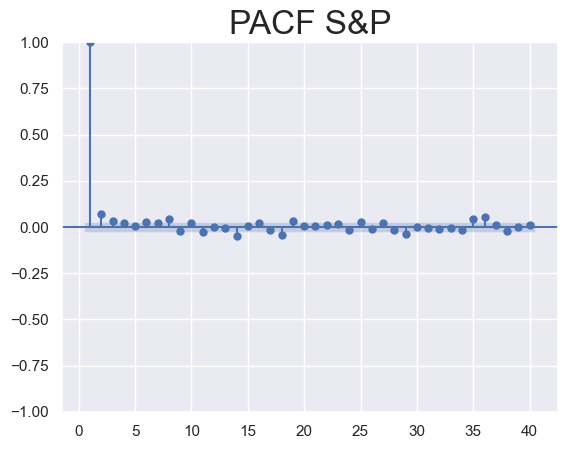

In [2]:
# now we plot the PACF for market value
sgt.plot_pacf(df.market_value,lags=40,zero=False,method='ols')
# there are several method to determine PACF here we use ORDER OF LEAST SQUARE (OLS)
plt.title("PACF S&P",size=24)
plt.show()

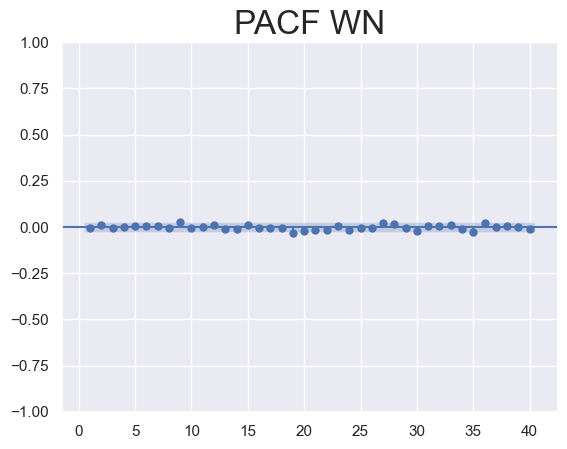

In [3]:
# now we plot the PACF for white noise
sgt.plot_pacf(df.wn,lags=40,zero=False,method='ols')
# there are several method to determine PACF here we use ORDER OF LEAST SQUARE (OLS)
plt.title("PACF WN",size=24)
plt.show()

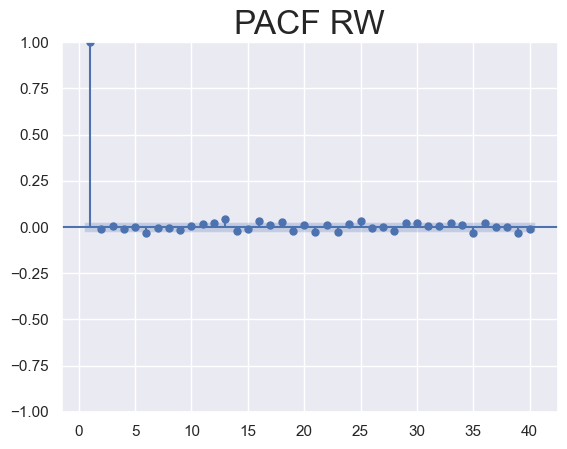

In [4]:
# now we plot the PACF for random walk
sgt.plot_pacf(df.rw,lags=40,zero=False,method='ols')
# there are several method to determine PACF here we use ORDER OF LEAST SQUARE (OLS)
plt.title("PACF RW",size=24)
plt.show()